In [1]:
%matplotlib inline 

In [ ]:
# Imports
import os
import pathlib
import urllib.request

# Site name for Salvus Flow. Uses env var if available, otherwise falls back to local site name.
SALVUS_FLOW_SITE_NAME = os.environ.get("SALVUS_FLOW_SITE_NAME", "salome_remote_2")
PROJECT_DIR = "simulation_wavefield_custom_stf_from_mpm_only_taper" 

# Conservative default to reduce license-seat demand during unstable license-server periods.
RANKS_PER_JOB = 4


def check_license_server_reachable(url="https://l.mondaic.com/licensing_server", timeout=10):
    """Fail fast if licensing endpoint is unreachable to avoid long hanging jobs."""
    try:
        with urllib.request.urlopen(url, timeout=timeout):
            return True
    except Exception as exc:
        raise RuntimeError(
            f"Licensing server not reachable ({url}). Retry later or check network/VPN. Original error: {exc}"
        ) from exc


# # Add code to keep .gitignore updated to ignore salvus files
# gitignore_path = pathlib.Path("..") / ".gitignore"
# with open(gitignore_path, "r+") as f:
#     contents = f.read()
#     if PROJECT_DIR not in contents:
#         f.write(f"\n{PROJECT_DIR}/\n")


import numpy as np
import salvus.namespace as sn
import salvus.flow.simple_config as sc
import xarray as xr
import salvus.namespace as sn
from salvus.project.tools.processing import block_processing
from salvus.toolbox.helpers.wavefield_output import (
    WavefieldOutput,
    wavefield_output_to_xarray,
)
import matplotlib.pyplot as plt
from matplotlib import animation
import obspy

# For wavefield output code
from salvus.mesh.unstructured_mesh_utils import read_model_from_h5
from salvus.toolbox.helpers import wavefield_output
import salvus.flow.api

#for plotting of wiggles, traces 
from scipy import signal

# For animation plot
from IPython.display import HTML
from matplotlib.collections import PolyCollection
import threading
import matplotlib
matplotlib.use("Agg")
from scipy.interpolate import griddata


   ┌────────────────────────────────────────────────────────────────────────────────────┐
   │                                                                                    │
   │   Salvus update available!                                                         │
   │                                                                                    │
   │   2025.1.2 → 2026.5.0                                                              │
   │                                                                                    │
   │   See https://docs.mondaic.com/updates/changelog                                   │
   │   for a list of changes and new features.                                          │
   │                                                                                    │
   │   To upgrade, please first make sure that your python environment is up to date:   │
   │                                                                                    │
   │   ht

In [3]:
domain_2d = sn.domain.dim2.BoxDomain(x0=0, x1=400, y0=0, y1=3)

p = sn.Project.from_domain(path=PROJECT_DIR, domain=domain_2d, load_if_exists=True)


Accordion()

[2026-07-17 10:19:30,965] INFO: Loading project from simulation_wavefield_custom_stf_from_mpm.


Keys in the NPZ file: ['times', 'x_centers', 'y_centers', 'M11', 'M22', 'M12', 'dM11', 'dM12', 'dM22']


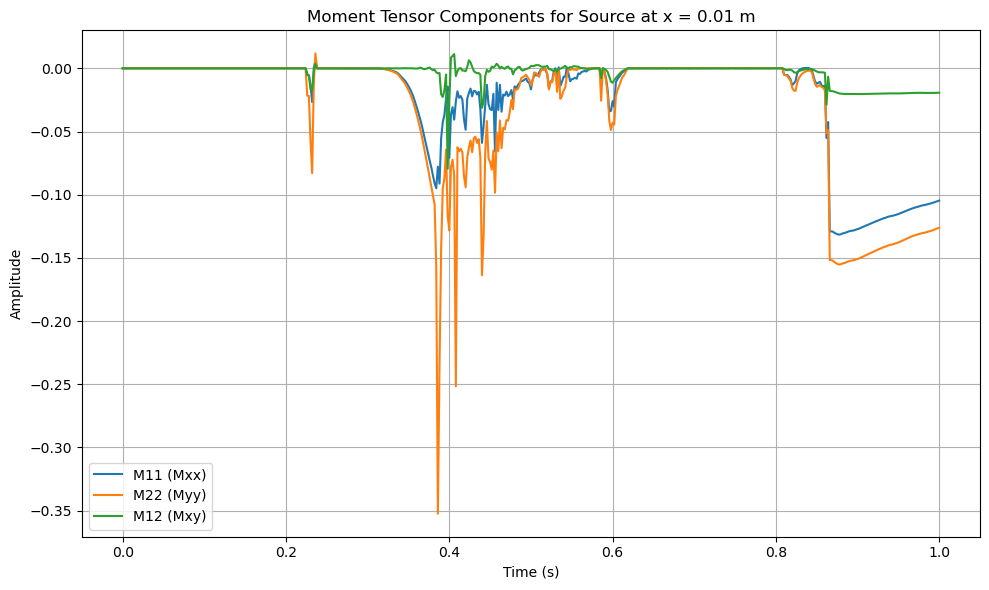

In [4]:
import numpy as np
import matplotlib.pyplot as plt

#Load  .npz archive
data = np.load('test_mpm_mij_B-reference_tau0p3549s.npz')

# Check keys of arrays inside
print("Keys in the NPZ file:", data.files)

# Extract the coordinate and time arrays
times = data['times']
x_centers = data['x_centers']

# Extract Moment Tensor Components and rename them to be the same as slavus 
m11 = np.squeeze(data['M11']) 
m22 = np.squeeze(data['M22']) 
m12 = np.squeeze(data['M12'])


# Plot components of 0th source to check 
source_idx = 0

if m11.shape[0] == len(times):
    y11 = m11[:, source_idx]
    y22 = m22[:, source_idx]
    y12 = m12[:, source_idx]
else:
    y11 = m11[source_idx, :]
    y22 = m22[source_idx, :]
    y12 = m12[source_idx, :]

plt.figure(figsize=(10, 6))
plt.plot(times, y11, label='M11 (Mxx)', linewidth=1.5)
plt.plot(times, y22, label='M22 (Myy)', linewidth=1.5)
plt.plot(times, y12, label='M12 (Mxy)', linewidth=1.5)

plt.title(f'Moment Tensor Components for Source at x = {x_centers[source_idx]:.2f} m')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.tight_layout()
display(plt.gcf())
plt.close()

In [5]:
# print y center of a source to check
y_data = data['y_centers']
print(y_data)

[0.37500001]


In [ ]:
# FFT of source to check specturem
# time-step (dt) and sampling rate (fs) from from times
dt = times[1] - times[0]
fs = 1.0 / dt
N = len(times)

# 2FFT and corresponding frequencies
frequencies = np.fft.rfftfreq(N, d=dt)
fft_y11 = np.abs(np.fft.rfft(y11))
fft_y22 = np.abs(np.fft.rfft(y22))
fft_y12 = np.abs(np.fft.rfft(y12))

plt.figure(figsize=(10, 6))
plt.plot(frequencies, fft_y11, label='M11 (Mxx) Spectrum', linewidth=1.5)
plt.plot(frequencies, fft_y22, label='M22 (Myy) Spectrum', linewidth=1.5)
plt.plot(frequencies, fft_y12, label='M12 (Mxy) Spectrum', linewidth=1.5)


plt.axvline(x=300.0, color='red', linestyle='--', linewidth=2, 
            label='Salvus Mesh Limit (300 Hz)')

plt.title(f'Frequency Spectrum for Source at x = {x_centers[source_idx]:.2f} m')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude / Energy')

plt.xlim(-50, 600) 

plt.legend()
plt.grid(True, which='both', linestyle=':')
plt.tight_layout()
display(plt.gcf())
plt.close()


In [ ]:
from scipy.signal import butter, sosfilt
# Load mpm data
print("Loading raw MPM moment tensor data...")
npz_data = np.load('test_mpm_mij_B-reference_tau0p3549s.npz')

times = npz_data['times']
x_coords = npz_data['x_centers']
y_coords = npz_data['y_centers']

# Calculate the exact native sampling rate of the MPM data
dt = times[1] - times[0]
sampling_rate = 1.0 / dt

print(f"Number of sources: {len(x_coords)}")
print(f"Number of time steps: {len(times)}")
print(f"Native sampling rate: {sampling_rate:.2f} Hz (dt = {dt:.6f} s)")

# Extract the raw moment tensor components and squeeze dummy dimensions
m11_raw = np.squeeze(npz_data['M11'])
m22_raw = np.squeeze(npz_data['M22'])
m12_raw = np.squeeze(npz_data['M12'])

# Ensure axes are aligned to: (Time Steps, Sources)
if m11_raw.shape[0] == len(times):
    m11 = m11_raw
    m22 = m22_raw
    m12 = m12_raw
else:
    m11 = m11_raw.T
    m22 = m22_raw.T
    m12 = m12_raw.T

n_sources = len(x_coords) 

# Dynamically handle y-coordinates if they are a flat scalar or a list
if np.ndim(y_coords) == 0 or len(np.atleast_1d(y_coords)) == 1:
    y_val = float(np.atleast_1d(y_coords)[0])
    y_coords = np.full_like(x_coords, y_val)

taper_percentage = 0.20  
N_taper = int(n_sources * taper_percentage)
N_taper = max(5, min(N_taper, int(n_sources * 0.45)))

source_taper = np.ones(n_sources)
source_taper[:N_taper]  = np.hanning(2 * N_taper)[:N_taper]
source_taper[-N_taper:] = np.hanning(2 * N_taper)[N_taper:]

# # Temporal Butterworth Low-Pass Filter (removes unphysical high-frequency grid noise)
# def lowpass_filter(signal, cutoff=60.0, fs=sampling_rate, order=4):
#     nyq = 0.5 * fs
#     normal_cutoff = cutoff / nyq
#     sos = butter(order, normal_cutoff, btype='low', output='sos')
#     return sosfilt(sos, signal)


# Tail Taper to smoothly fade out active signals at the end of simulation
n_samples = len(times)
tail_taper_len = int(0.10 * n_samples)# 10% smooth tail ramp-down
tail_taper = np.ones(n_samples)
tail_taper[-tail_taper_len:] = np.hanning(2 * tail_taper_len)[tail_taper_len:]


# Create salvus sources 1:1
srcs = []

for i in range(len(x_coords)):
    # Raw, unchanged time series for this source index
    mxx = m11[:, i] * source_taper[i] 
    myy = m22[:, i] * source_taper[i]
    mxy = m12[:, i] * source_taper[i]

    # cutoff_freq = 60
    
    # mxx_filt = lowpass_filter(mxx, cutoff=cutoff_freq, fs=sampling_rate)
    # myy_filt = lowpass_filter(myy, cutoff=cutoff_freq, fs=sampling_rate)
    # mxy_filt = lowpass_filter(mxy, cutoff=cutoff_freq, fs=sampling_rate)

    # Apply the tail-taper to eliminate the shutoff shock at t = 1.0s
    mxx_clean = mxx * tail_taper
    myy_clean = myy * tail_taper
    mxy_clean = mxy* tail_taper

    

    stf_array = np.column_stack((mxx_clean, myy_clean, mxy_clean))
    
    # Buld salvus source
    stf = sc.stf.Custom.from_array(
        array=stf_array,
        sampling_rate_in_hertz=sampling_rate,
        start_time_in_seconds=times[0], 
    )
    
    # Build sources with shifted coordinates to avoid boundary issues
    src = sc.source.cartesian.MomentTensorPoint2D(
        x=40+float(x_coords[i]),
        y=2.3 +float(y_coords[i]),
        mxx=1.0,
        myy=1.0,
        mxy=1.0,
        source_time_function=stf,
    )
    srcs.append(src)

print(f"Successfully generated {len(srcs)} sources directly from the MPM file.")


Loading raw MPM moment tensor data...
Number of sources: 4000
Number of time steps: 501
Native sampling rate: 500.00 Hz (dt = 0.002000 s)
Successfully generated 4000 sources directly from the MPM file.


In [7]:

# # Compute dominant wavelength to size the buffer zone
# vs_slab = 67.9  # calculated m/s
# lambda_dominant = vs_slab / dominant_frequency_value # Use M11 component for frequency analysis

# # 2 wavelengths of extra elements between the source array and the ABC edge
# x_buffer = 30.0

# # Define physical domain boundaries (Excluding the ABC padding itself)
# x_min = 0.0
# x_max = 40.0 + (2.0 * x_buffer) # Extend both sides equitably 


# mpm_total_height = 0.3 + 0.15 + 0.3 
# y_salvus_base = 3.0 - mpm_total_height # y=2.25m

# # MPM Weak Layer center depth relative to MPM base (0.3m bed + half of 0.15m WL)
# mpm_wl_center_y = 0.3 + (0.15 / 2.0)  # 0.375 m

# print(f"Domain Setup:")
# print(f"  Left Buffer Room before sources: {x_buffer:.2f} m")
# print(f"  Salvus Weak Layer target depth: {y_salvus_base + mpm_wl_center_y:.3f} m")

# # Loadn and taper mpm data
# npz_data = np.load('test_mpm_mij_B-reference_tau0p3549s.npz')
# times = npz_data['times']
# x_coords = npz_data['x_centers']
# dt = times[1] - times[0]
# sampling_rate = 1.0 / dt

# m11 = np.squeeze(npz_data['M11']).T if np.squeeze(npz_data['M11']).shape[0] != len(times) else np.squeeze(npz_data['M11'])
# m22 = np.squeeze(npz_data['M22']).T if np.squeeze(npz_data['M22']).shape[0] != len(times) else np.squeeze(npz_data['M22'])
# m12 = np.squeeze(npz_data['M12']).T if np.squeeze(npz_data['M12']).shape[0] != len(times) else np.squeeze(npz_data['M12'])

# # Dynamic check for y_centers
# if 'y_centers' in npz_data.files:
#     y_coords = npz_data['y_centers']
#     #
#     if y_coords.size == 1:
#         y_coords = np.full_like(x_coords, float(y_coords))
# else:
#     # Safe fallback if missing, using the explicitly verified WL center
#     y_coords = np.full_like(x_coords, mpm_wl_center_y)

# n_sources = len(x_coords)

# # 20% spatial taper to smoothly phase out edge transients
# taper_percentage = 0.30 
# N_taper = int(n_sources * taper_percentage)
# N_taper = max(5, min(N_taper, int(n_sources * 0.45)))

# source_taper = np.ones(n_sources)
# source_taper[:N_taper]  = np.hanning(2 * N_taper)[:N_taper]
# source_taper[-N_taper:] = np.hanning(2 * N_taper)[N_taper:]

# # =Generate sources with mapped coordinates and tapered moment tensors
# srcs = []
# x_salvus_all = []
# y_salvus_all = []

# for i in range(n_sources):
#     # Apply amplitude taper to components
#     mxx = m11[:, i] * source_taper[i] 
#     myy = m22[:, i] * source_taper[i]
#     mxy = m12[:, i] * source_taper[i]
#     stf_array = np.column_stack((mxx, myy, mxy))

#     stf = sc.stf.Custom.from_array(
#         array=stf_array,
#         sampling_rate_in_hertz=sampling_rate,
#         start_time_in_seconds=times[0],
#     )

#     # Shift positions cleanly down the domain past the left near-field buffer
#     x_s = x_buffer + float(x_coords[i])
#     y_s = y_salvus_base + float(y_coords[i])

#     x_salvus_all.append(x_s)
#     y_salvus_all.append(y_s)

    
#     src = sc.source.cartesian.MomentTensorPoint2D(
#         x=x_s,
#         y=y_s,
#         mxx=1.0,
#         myy=1.0,
#         mxy=1.0,
#         source_time_function=stf,
#     )
#     srcs.append(src)

# print(f"Generated {len(srcs)} sources mapped between x=[{min(x_salvus_all):.2f}, {max(x_salvus_all):.2f}] m.")

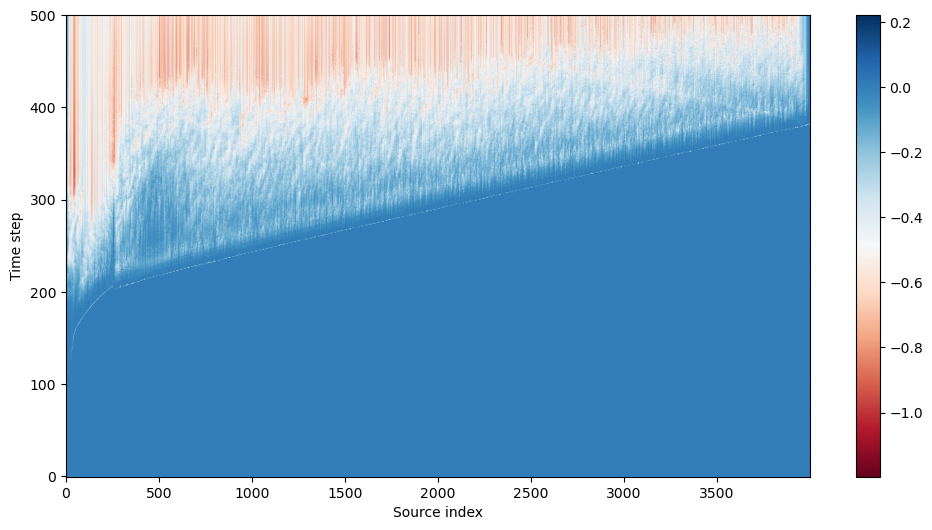

In [8]:
# Plotting one moment tensor component

plt.figure(figsize=(12,6))
plt.imshow(
    m11,
    aspect='auto',
    cmap='RdBu',
    origin='lower'
)
plt.xlabel("Source index")
plt.ylabel("Time step")
plt.colorbar()
display(plt.gcf())
plt.close()

In [9]:
srcs

[{'location': [40.00500066615944, 2.675000014901161],
  'source_time_function': {'dataset_name': '/stf',
                           'filename': '/tmp/salvus_internal_tmp_sbachmann/salvus.flow_custom_stf__2607171019649218ade9ec78__2436125/custom_stf.h5',
                           'wavelet': 'custom'},
  'spatial_type': 'moment_tensor',
  'spatial_weights': [1.0, 1.0, 1.0]},
 {'location': [40.01500061639561, 2.675000014901161],
  'source_time_function': {'dataset_name': '/stf',
                           'filename': '/tmp/salvus_internal_tmp_sbachmann/salvus.flow_custom_stf__260717101965234128e2729d__2436125/custom_stf.h5',
                           'wavelet': 'custom'},
  'spatial_type': 'moment_tensor',
  'spatial_weights': [1.0, 1.0, 1.0]},
 {'location': [40.02500056663179, 2.675000014901161],
  'source_time_function': {'dataset_name': '/stf',
                           'filename': '/tmp/salvus_internal_tmp_sbachmann/salvus.flow_custom_stf__2607171019654622763bbf0f__2436125/custom_s

In [10]:
import h5py


h5_path = srcs[0].source_time_function.filename
dataset_name = srcs[0].source_time_function.dataset_name
wavelet_type = srcs[0].source_time_function.wavelet

print(f"Wavelet Type: {wavelet_type}")
print(f"HDF5 File Location: {h5_path}")
print(f"Dataset Name inside HDF5: {dataset_name}\n")

# Open  file to look at the raw custom wavelet data structure
with h5py.File(h5_path, 'r') as f:
    dset = f[dataset_name]
    
    print("--- Dataset Details ---")
    print("Array Shape (n_components, n_samples):", dset.shape)
    print("Data Type:", dset.dtype)
    
    print("\n--- Meta-Data Attributes Attached by Salvus ---")
    for key, val in dset.attrs.items():
        print(f"  {key}: {val}")
        
    # first 10 numerical values of the actual wavelet array
    print("\nFirst 10 amplitude values of the custom array:")
    print(dset[:10])

    

Wavelet Type: custom
HDF5 File Location: /tmp/salvus_internal_tmp_sbachmann/salvus.flow_custom_stf__2607171019649218ade9ec78__2436125/custom_stf.h5
Dataset Name inside HDF5: /stf

--- Dataset Details ---
Array Shape (n_components, n_samples): (501, 3)
Data Type: float64

--- Meta-Data Attributes Attached by Salvus ---
  sampling_rate_in_hertz: 500.0
  start_time_in_seconds: 0.0

First 10 amplitude values of the custom array:
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]


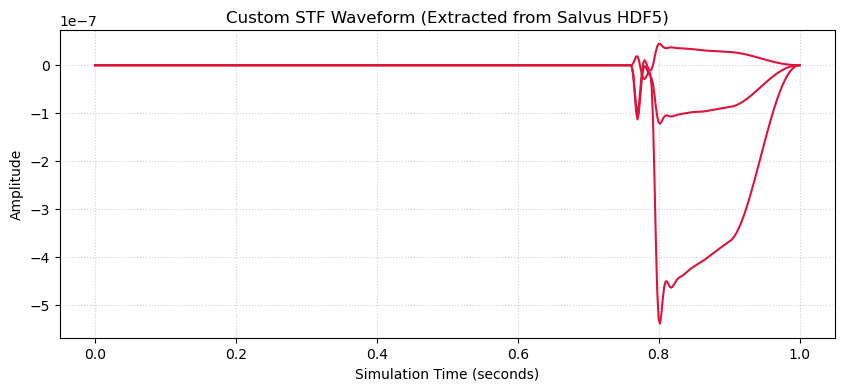

In [11]:


# Path and dataset pointer form object for first source 
h5_path = srcs[3998].source_time_function.filename
dataset_name = srcs[3998].source_time_function.dataset_name

# Extract the array and metadata from the HDF5 file
with h5py.File(h5_path, 'r') as f:
    dset = f[dataset_name]
    stf_array = np.squeeze(dset[:]) # Squeeze removes empty dimensions 
    
    # Extract attributes
    sampling_rate = dset.attrs.get('sampling_rate_in_hertz', 10000.0)
    start_time = dset.attrs.get('start_time_in_seconds', 0.0)

# Time axis of soutce 
dt = 1.0 / sampling_rate
time_axis = start_time + (np.arange(len(stf_array)) * dt)


plt.figure(figsize=(10, 4))
plt.plot(time_axis, stf_array, color='crimson', lw=1.5)
plt.xlabel('Simulation Time (seconds)')
plt.ylabel('Amplitude')
plt.title('Custom STF Waveform (Extracted from Salvus HDF5)')
plt.grid(True, linestyle=':', alpha=0.6)
display(plt.gcf())
plt.close()

In [12]:


# Defining materials
snow_mat = sn.material.from_params(rho=250.0,  vp=109.4, vs=67.9366)
slab_mat = sn.material.from_params(rho=250.0,  vp=109.4, vs=67.9366)
air_mat  = sn.material.from_params(rho=1.225,  vp=300.0)

# Model boundaries top to bottom
interface_snow_slab = sn.layered_meshing.interface.Hyperplane.at(2.25)
interface_slab_air  = sn.layered_meshing.interface.Hyperplane.at(1.5)

# Assemble into a LayeredModel structure (Layers and Interfaces alternative sequence)
model_layers = sn.layered_meshing.LayeredModel([
    snow_mat, 
    interface_snow_slab, 
    slab_mat, 
    interface_slab_air, 
    air_mat
]
)

domain_2d = sn.domain.dim2.BoxDomain(
    x0=0.0, x1=400.0,
    y0=0.0, y1=3.0
)

f0 = 1.0
max_frequency = 300.0



# Generate mesh 
mesh_3layer = sn.layered_meshing.mesh_from_domain(
    domain=domain_2d,
    model=model_layers,
    mesh_resolution=sn.MeshResolution(reference_frequency = max_frequency), 

)

print("Simplified Layered Mesh Built successfully!")




# One per layer pair; last value keeps meshing stable above acoustic air.
slowest_velocities = np.array([150.0, 150.0,  150.0])

# calculating the wavelength of the center freqnecy (lambda = v / f)
wavelengths = float(slowest_velocities[0] / 20)
abc_thickness = wavelengths*3.5
print(f"Calculated minimum thickness for ABC: {abc_thickness:.2f} m")

Simplified Layered Mesh Built successfully!
Calculated minimum thickness for ABC: 26.25 m


In [13]:
# Initialize simulation object, pass multiple sources
sim = sc.simulation.Waveform(mesh=mesh_3layer, sources=srcs)

# physics parameters 
sim.physics.wave_equation.end_time_in_seconds = 6.545
sim.physics.wave_equation.start_time_in_seconds = -0.2

abc_sides = sc.boundary.Absorbing(
    width_in_meters=float(abc_thickness), 
    side_sets=["x0", "x1"],
    taper_amplitude=300.0 * 2.0,
    side_sets_are_axis_aligned=True
)

abc_bottom = sc.boundary.Absorbing(
    width_in_meters=1.0, 
    side_sets=["y0"],
    taper_amplitude=300.0 * 2.0,
    side_sets_are_axis_aligned=True
)

sim.physics.wave_equation.boundaries = [abc_sides, abc_bottom]

sim.output.volume_data.format = "hdf5"
sim.output.volume_data.fields = ["displacement", "velocity"]
sim.output.volume_data.filename = "volume_data_output.h5"
sim.output.volume_data.sampling_interval_in_time_steps = 50


moving_source_output_folder = str(pathlib.Path(PROJECT_DIR) / "custom_job_moving_source_all_sources")

print(f"Launching simulation. Outputs will be copied to: {moving_source_output_folder}")


Launching simulation. Outputs will be copied to: simulation_wavefield_custom_stf_from_mpm/custom_job_moving_source_all_sources


In [14]:

# Launchg
salvus.flow.api.run(
    input_file=sim,
    site_name=SALVUS_FLOW_SITE_NAME,
    ranks=RANKS_PER_JOB,
    output_folder=moving_source_output_folder,
    overwrite=True,
    get_all=True, 
)

print("Run finished successfully!")

SalvusJob `job_2607171019176884_a17ee42c10` running on `salome_remote_2` with 4 rank(s).
Site information:
  * Salvus version: 2025.1.2
  * Floating point size: 32


Solving forward problem/Computing forward wavefield:   0%|          | 0/173021 [00:00<?, ?it/s]

* Downloaded 43.8 GB of results to `simulation_wavefield_custom_stf_from_mpm/custom_job_moving_source_all_sources`.
* Total run time: 1431.67 seconds.
* Pure simulation time: 1355.55 seconds.
Run finished successfully!


In [15]:
vol_file = pathlib.Path(moving_source_output_folder) / "volume_data_output.h5"
if not vol_file.exists():
    raise RuntimeError(
        f"Missing output file: {vol_file}. Re-run the launch cell and verify the job completed."
    )

vel_wo = wavefield_output.WavefieldOutput.from_file(
    vol_file,
    "velocity",
    "volume",
)

vel_2d_layered = wavefield_output.wavefield_output_to_xarray(
    vel_wo,
    points=[np.linspace(0, 400, 1601), np.linspace(0, 3, 101)],
)

print(f"Loaded velocity from {vol_file}")
print(f"Shape: {vel_2d_layered.dims}")
print(vel_2d_layered)

Finding enclosing elements (pass 1 of auto):   0%|          | 0/161701 [00:00<?, ?it/s]

Finding enclosing elements (pass 2 of auto):   0%|          | 0/80050 [00:00<?, ?it/s]

Finding enclosing elements (pass 3 of auto):   0%|          | 0/80050 [00:00<?, ?it/s]

Finding enclosing elements (pass 4 of auto):   0%|          | 0/80050 [00:00<?, ?it/s]

Finding enclosing elements (pass 5 of auto):   0%|          | 0/80050 [00:00<?, ?it/s]

Finding enclosing elements (pass 6 of auto):   0%|          | 0/80050 [00:00<?, ?it/s]

[2026-07-17 10:45:12,863] WARNING - salvus.mesh.algorithms.unstructured_mesh.utils: 80050 points were not claimed by enclosing elements. Depending on your use case, this may not be an issue.


Extracting wavefield to regular grid:   0%|          | 0/3 [00:00<?, ?it/s]

Loaded velocity from simulation_wavefield_custom_stf_from_mpm/custom_job_moving_source_all_sources/volume_data_output.h5
Shape: ('t', 'c', 'x', 'y')
<xarray.DataArray (t: 3462, c: 2, x: 1601, y: 101)> Size: 4GB
array([[[[            nan,             nan,             nan, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         [            nan,             nan,             nan, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         [            nan,             nan,             nan, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         ...,
         [            nan,             nan,             nan, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         [            nan,             nan,             nan, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         [            nan,             nan,             nan, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00]],

     

Using dimensions: {'x': 'x', 'y': 'y', 't': 't', 'c': 'c', 'event': None}
t range: -0.2 -> 6.546130527508221
vx shape: (3462, 1601)
vy shape: (3462, 1601)


/tmp/ipykernel_2436125/1095561471.py:56: UserWarning: shading value 'none' not in list of valid values ['gouraud', 'nearest', 'flat', 'auto']. Setting shading='auto'.
  im_vx = axes[0].pcolormesh(
/tmp/ipykernel_2436125/1095561471.py:78: UserWarning: shading value 'none' not in list of valid values ['gouraud', 'nearest', 'flat', 'auto']. Setting shading='auto'.
  im_vy = axes[1].pcolormesh(


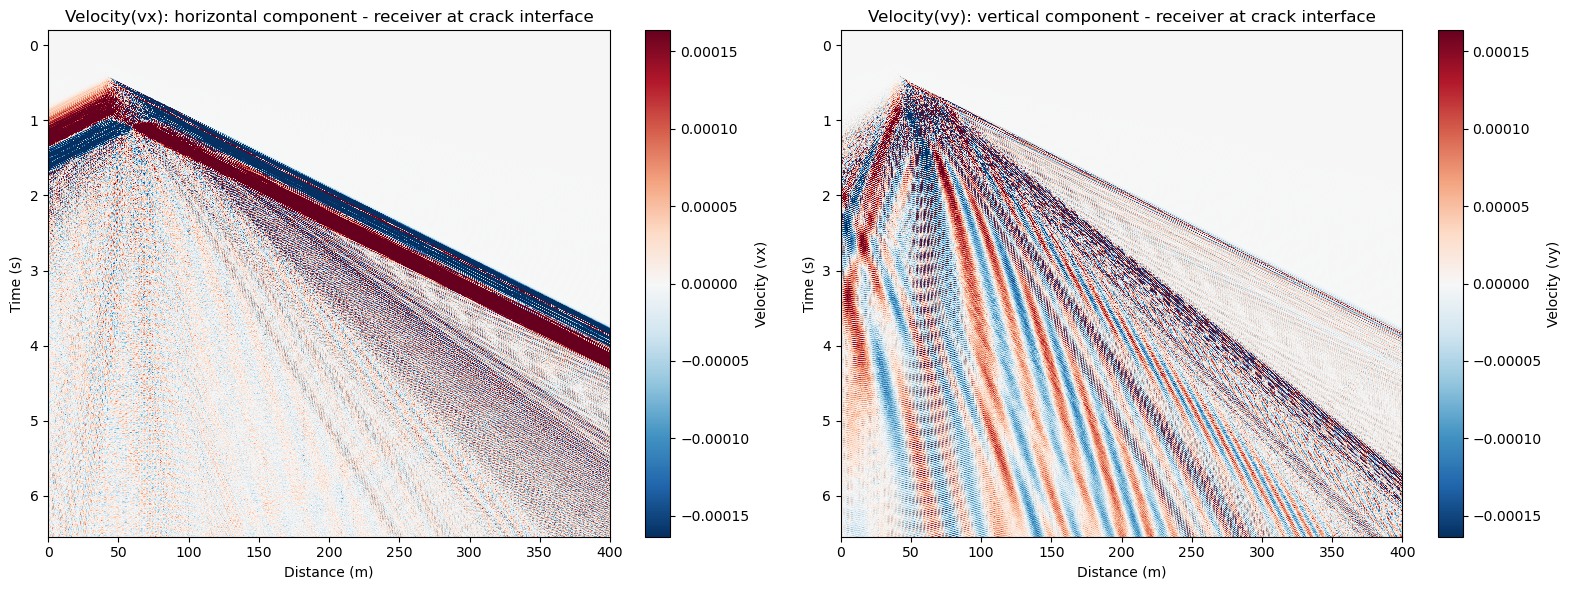

In [16]:
# Force inline display in case backend was set to Agg earlier
import matplotlib.pyplot as plt
from IPython.display import display

# Define receiver line 
y_surface = 2.625 # 

# dis_2d_layered is already an xarray built from all events.
# Use direct selection instead of calling wavefield_output_to_xarray again.
    
# Resolve coordinate / dimension names robustly.
coords_set = set(vel_2d_layered.coords)
dims_set = set(vel_2d_layered.dims)

x_name = next((n for n in ["x", "X", "p0", "dim_0"] if n in coords_set or n in dims_set), None)
y_name = next((n for n in ["y", "Y", "p1", "dim_1"] if n in coords_set or n in dims_set), None)
t_name = next((n for n in ["t", "time"] if n in coords_set or n in dims_set), None)
c_name = next((n for n in ["c", "component"] if n in coords_set or n in dims_set), None)
e_name = next((n for n in ["event_index", "event", "source"] if n in coords_set or n in dims_set), None)

if x_name is None or y_name is None or t_name is None or c_name is None:
    raise ValueError(f"Could not resolve required dimensions. Found dims={vel_2d_layered.dims}, coords={list(vel_2d_layered.coords)}")

# Select both components at y receiver line
sg_vx = vel_2d_layered.isel({c_name: 0}).sel({y_name: y_surface}, method="nearest")
sg_vy = vel_2d_layered.isel({c_name: 1}).sel({y_name: y_surface}, method="nearest")

# Keep all moving-source events by reducing event dimension to a single stacked section.
if e_name is not None and e_name in sg_vx.dims:
    sg_vx_plot = sg_vx.mean(dim=e_name)
    sg_vy_plot = sg_vy.mean(dim=e_name)
else:
    sg_vx_plot = sg_vx
    sg_vy_plot = sg_vy

# Ensure plotting order is (time, x)
sg_vx_plot = sg_vx_plot.transpose(t_name, x_name)
sg_vy_plot = sg_vy_plot.transpose(t_name, x_name)

t_vals = sg_vx_plot[t_name].values
x_line = sg_vx_plot[x_name].values
data_vx = sg_vx_plot.values
data_vy = sg_vy_plot.values

print("Using dimensions:", {"x": x_name, "y": y_name, "t": t_name, "c": c_name, "event": e_name})
print("t range:", t_vals[0], "->", t_vals[-1])
print("vx shape:", data_vx.shape)
print("vy shape:", data_vy.shape)

# Clip colorscale (use same scale for both for comparison)
vmax = np.percentile(np.abs([data_vx, data_vy]), 95)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot vx (horizontal component)
im_vx = axes[0].pcolormesh(
    x_line,
    t_vals,
    data_vx,
    shading="none",
    cmap="RdBu_r",
    vmin=-vmax,
    vmax=vmax,
)
axes[0].invert_yaxis()

# Mark all moving source positions
# for x_src in x_positions:
#     axes[0].axvline(x=x_src, color="teal", lw=0.5, linestyle="--", alpha=0.35)

axes[0].set_xlabel("Distance (m)")
axes[0].set_ylabel("Time (s)")
axes[0].set_xlim(0, 400)
axes[0].set_title("Velocity(vx): horizontal component - receiver at crack interface")
plt.colorbar(im_vx, ax=axes[0], label="Velocity (vx)")

# Plot vy (vertical component)
im_vy = axes[1].pcolormesh(
    x_line,
    t_vals,
    data_vy,
    shading="none",
    cmap="RdBu_r",
    vmin=-vmax,
    vmax=vmax,
)
axes[1].invert_yaxis()

# # Mark all moving source positions
# for x_src in x_positions:
#     axes[1].axvline(x=x_src, color="teal", lw=0.5, linestyle="--", alpha=0.35)

axes[1].set_xlabel("Distance (m)")
axes[1].set_ylabel("Time (s)")
axes[1].set_xlim(0, 400)
axes[1].set_title("Velocity(vy): vertical component - receiver at crack interface")
plt.colorbar(im_vy, ax=axes[1], label="Velocity (vy)")

plt.tight_layout()

# Display explicitly in notebook output
display(fig)
plt.close(fig)

Using dimensions: {'x': 'x', 'y': 'y', 't': 't', 'c': 'c', 'event': None}
t range: -0.2 -> 6.546130527508221
vx shape: (3462, 1601)
vy shape: (3462, 1601)


/tmp/ipykernel_2436125/1981987164.py:59: UserWarning: shading value 'none' not in list of valid values ['gouraud', 'nearest', 'flat', 'auto']. Setting shading='auto'.
  im_vx = axes[0].pcolormesh(
/tmp/ipykernel_2436125/1981987164.py:81: UserWarning: shading value 'none' not in list of valid values ['gouraud', 'nearest', 'flat', 'auto']. Setting shading='auto'.
  im_vy = axes[1].pcolormesh(


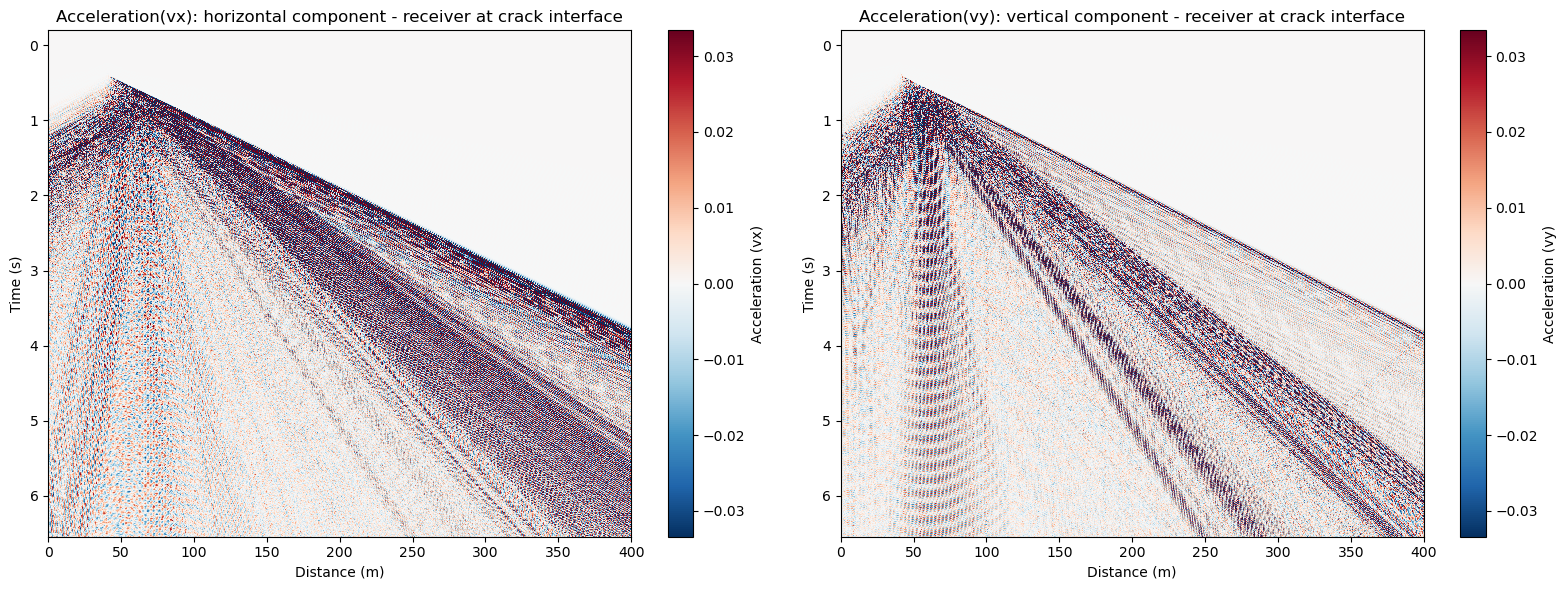

In [17]:
acc_2d_layered = vel_2d_layered.differentiate(t_name)


# Force inline display in case backend was set to Agg earlier
import matplotlib.pyplot as plt
from IPython.display import display

# Define receiver line 
y_surface = 2.625 # 

# dis_2d_layered is already an xarray built from all events.
# Use direct selection instead of calling wavefield_output_to_xarray again.
    
# Resolve coordinate / dimension names robustly.
coords_set = set(acc_2d_layered.coords)
dims_set = set(acc_2d_layered.dims)

x_name = next((n for n in ["x", "X", "p0", "dim_0"] if n in coords_set or n in dims_set), None)
y_name = next((n for n in ["y", "Y", "p1", "dim_1"] if n in coords_set or n in dims_set), None)
t_name = next((n for n in ["t", "time"] if n in coords_set or n in dims_set), None)
c_name = next((n for n in ["c", "component"] if n in coords_set or n in dims_set), None)
e_name = next((n for n in ["event_index", "event", "source"] if n in coords_set or n in dims_set), None)

if x_name is None or y_name is None or t_name is None or c_name is None:
    raise ValueError(f"Could not resolve required dimensions. Found dims={acc_2d_layered.dims}, coords={list(acc_2d_layered.coords)}")

# Select both components at y receiver line
sg_vx = acc_2d_layered.isel({c_name: 0}).sel({y_name: y_surface}, method="nearest")
sg_vy = acc_2d_layered.isel({c_name: 1}).sel({y_name: y_surface}, method="nearest")

# Keep all moving-source events by reducing event dimension to a single stacked section.
if e_name is not None and e_name in sg_vx.dims:
    sg_vx_plot = sg_vx.mean(dim=e_name)
    sg_vy_plot = sg_vy.mean(dim=e_name)
else:
    sg_vx_plot = sg_vx
    sg_vy_plot = sg_vy

# Ensure plotting order is (time, x)
sg_vx_plot = sg_vx_plot.transpose(t_name, x_name)
sg_vy_plot = sg_vy_plot.transpose(t_name, x_name)

t_vals = sg_vx_plot[t_name].values
x_line = sg_vx_plot[x_name].values
data_vx = sg_vx_plot.values
data_vy = sg_vy_plot.values

print("Using dimensions:", {"x": x_name, "y": y_name, "t": t_name, "c": c_name, "event": e_name})
print("t range:", t_vals[0], "->", t_vals[-1])
print("vx shape:", data_vx.shape)
print("vy shape:", data_vy.shape)

# Clip colorscale (use same scale for both for comparison)
vmax = np.percentile(np.abs([data_vx, data_vy]), 95)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot vx (horizontal component)
im_vx = axes[0].pcolormesh(
    x_line,
    t_vals,
    data_vx,
    shading="none",
    cmap="RdBu_r",
    vmin=-vmax,
    vmax=vmax,
)
axes[0].invert_yaxis()

# Mark all moving source positions
# for x_src in x_positions:
#     axes[0].axvline(x=x_src, color="teal", lw=0.5, linestyle="--", alpha=0.35)

axes[0].set_xlabel("Distance (m)")
axes[0].set_ylabel("Time (s)")
axes[0].set_xlim(0, 400)
axes[0].set_title("Acceleration(vx): horizontal component - receiver at crack interface")
plt.colorbar(im_vx, ax=axes[0], label="Acceleration (vx)")

# Plot vy (vertical component)
im_vy = axes[1].pcolormesh(
    x_line,
    t_vals,
    data_vy,
    shading="none",
    cmap="RdBu_r",
    vmin=-vmax,
    vmax=vmax,
)
axes[1].invert_yaxis()

# # Mark all moving source positions
# for x_src in x_positions:
#     axes[1].axvline(x=x_src, color="teal", lw=0.5, linestyle="--", alpha=0.35)

axes[1].set_xlabel("Distance (m)")
axes[1].set_ylabel("Time (s)")
axes[1].set_xlim(0, 400)
axes[1].set_title("Acceleration(vy): vertical component - receiver at crack interface")
plt.colorbar(im_vy, ax=axes[1], label="Acceleration (vy)")

plt.tight_layout()

# Display explicitly in notebook output
display(fig)
plt.close(fig)


Using dimensions: {'x': 'x', 'y': 'y', 't': 't', 'c': 'c', 'event': None}
t range: -0.2 -> 6.546130527508221
vx shape: (3462, 1601)
vy shape: (3462, 1601)


/tmp/ipykernel_2436125/1808668020.py:56: UserWarning: shading value 'none' not in list of valid values ['gouraud', 'nearest', 'flat', 'auto']. Setting shading='auto'.
  im_vx = axes[0].pcolormesh(
/tmp/ipykernel_2436125/1808668020.py:78: UserWarning: shading value 'none' not in list of valid values ['gouraud', 'nearest', 'flat', 'auto']. Setting shading='auto'.
  im_vy = axes[1].pcolormesh(


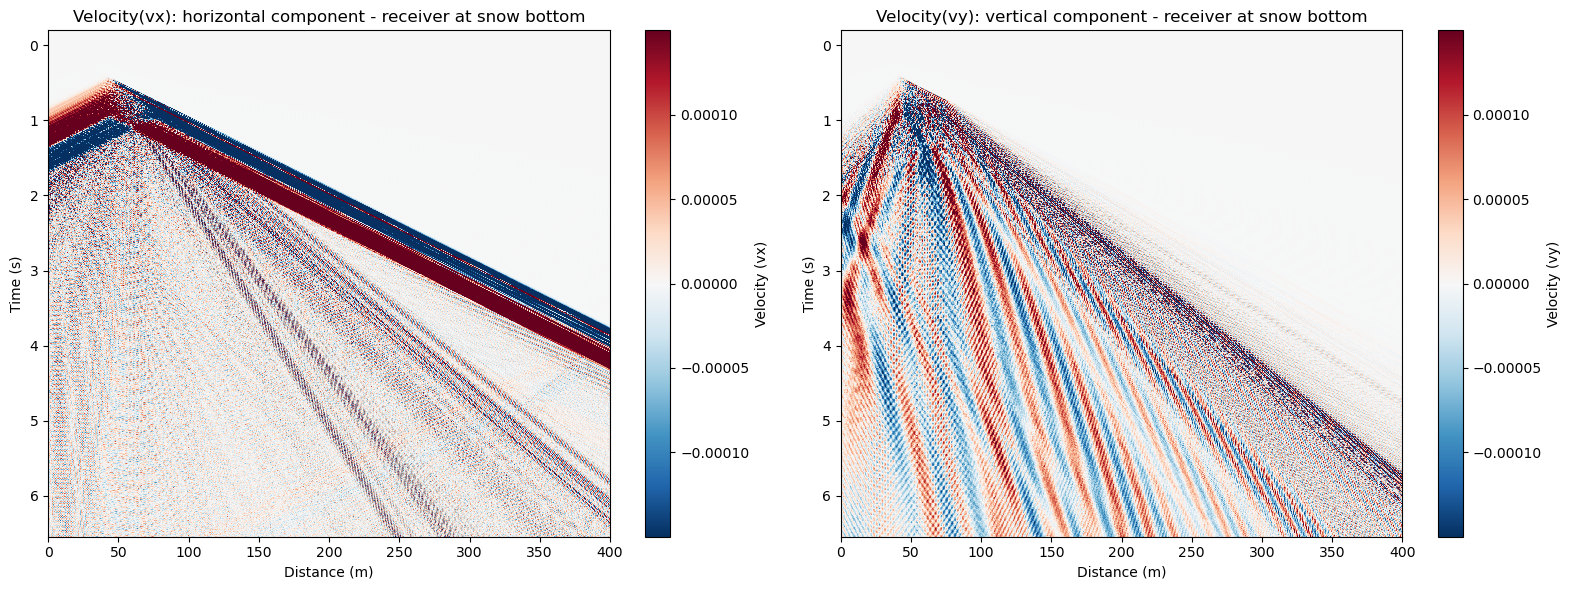

In [18]:
# Force inline display in case backend was set to Agg earlier
import matplotlib.pyplot as plt
from IPython.display import display

# Define receiver line 
y_surface = 2.25 # 

# dis_2d_layered is already an xarray built from all events.
# Use direct selection instead of calling wavefield_output_to_xarray again.
    
# Resolve coordinate / dimension names robustly.
coords_set = set(vel_2d_layered.coords)
dims_set = set(vel_2d_layered.dims)

x_name = next((n for n in ["x", "X", "p0", "dim_0"] if n in coords_set or n in dims_set), None)
y_name = next((n for n in ["y", "Y", "p1", "dim_1"] if n in coords_set or n in dims_set), None)
t_name = next((n for n in ["t", "time"] if n in coords_set or n in dims_set), None)
c_name = next((n for n in ["c", "component"] if n in coords_set or n in dims_set), None)
e_name = next((n for n in ["event_index", "event", "source"] if n in coords_set or n in dims_set), None)

if x_name is None or y_name is None or t_name is None or c_name is None:
    raise ValueError(f"Could not resolve required dimensions. Found dims={vel_2d_layered.dims}, coords={list(vel_2d_layered.coords)}")

# Select both components at y receiver line
sg_vx = vel_2d_layered.isel({c_name: 0}).sel({y_name: y_surface}, method="nearest")
sg_vy = vel_2d_layered.isel({c_name: 1}).sel({y_name: y_surface}, method="nearest")

# Keep all moving-source events by reducing event dimension to a single stacked section.
if e_name is not None and e_name in sg_vx.dims:
    sg_vx_plot = sg_vx.mean(dim=e_name)
    sg_vy_plot = sg_vy.mean(dim=e_name)
else:
    sg_vx_plot = sg_vx
    sg_vy_plot = sg_vy

# Ensure plotting order is (time, x)
sg_vx_plot = sg_vx_plot.transpose(t_name, x_name)
sg_vy_plot = sg_vy_plot.transpose(t_name, x_name)

t_vals = sg_vx_plot[t_name].values
x_line = sg_vx_plot[x_name].values
data_vx = sg_vx_plot.values
data_vy = sg_vy_plot.values

print("Using dimensions:", {"x": x_name, "y": y_name, "t": t_name, "c": c_name, "event": e_name})
print("t range:", t_vals[0], "->", t_vals[-1])
print("vx shape:", data_vx.shape)
print("vy shape:", data_vy.shape)

# Clip colorscale (use same scale for both for comparison)
vmax = np.percentile(np.abs([data_vx, data_vy]), 95)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot vx (horizontal component)
im_vx = axes[0].pcolormesh(
    x_line,
    t_vals,
    data_vx,
    shading="none",
    cmap="RdBu_r",
    vmin=-vmax,
    vmax=vmax,
)
axes[0].invert_yaxis()

# Mark all moving source positions
# for x_src in x_positions:
#     axes[0].axvline(x=x_src, color="teal", lw=0.5, linestyle="--", alpha=0.35)

axes[0].set_xlabel("Distance (m)")
axes[0].set_ylabel("Time (s)")
axes[0].set_xlim(0, 400)
axes[0].set_title("Velocity(vx): horizontal component - receiver at snow bottom")
plt.colorbar(im_vx, ax=axes[0], label="Velocity (vx)")

# Plot vy (vertical component)
im_vy = axes[1].pcolormesh(
    x_line,
    t_vals,
    data_vy,
    shading="none",
    cmap="RdBu_r",
    vmin=-vmax,
    vmax=vmax,
)
axes[1].invert_yaxis()

# # Mark all moving source positions
# for x_src in x_positions:
#     axes[1].axvline(x=x_src, color="teal", lw=0.5, linestyle="--", alpha=0.35)

axes[1].set_xlabel("Distance (m)")
axes[1].set_ylabel("Time (s)")
axes[1].set_xlim(0, 400)
axes[1].set_title("Velocity(vy): vertical component - receiver at snow bottom")
plt.colorbar(im_vy, ax=axes[1], label="Velocity (vy)")

plt.tight_layout()

# Display explicitly in notebook output
display(fig)
plt.close(fig)

In [19]:
# loading displacement
# Extract displacement wavefield output from the single combined run.
czm_output_folder = str(pathlib.Path(PROJECT_DIR) / "custom_job_moving_source_all_sources")
vol_file = pathlib.Path(czm_output_folder) / "volume_data_output.h5"
if not vol_file.exists():
    raise RuntimeError(
        f"Missing output file: {vol_file}. Re-run the launch cell and verify the job completed."
    )

dis_wo = wavefield_output.WavefieldOutput.from_file(
    vol_file,
    "displacement",
    "volume",
)

dis_2d_layered = wavefield_output.wavefield_output_to_xarray(
    dis_wo,
    points=[np.linspace(0, 400, 451), np.linspace(0, 3, 101)],
)

print(f"Loaded displacement from {vol_file}")
print(f"Shape: {dis_2d_layered.dims}")
print(dis_2d_layered)

# Take the spatial derivative of the layered displacement field along x.
x_dim = next((dim for dim in ["x", "X", "p0", "dim_0"] if dim in dis_2d_layered.dims or dim in dis_2d_layered.coords), None)

if x_dim is None:
    raise ValueError(
        f"Could not find an x-like spatial dimension in dims={dis_2d_layered.dims}, coords={list(dis_2d_layered.coords)}"
    )

dis_2d_layered_dx = dis_2d_layered.differentiate(x_dim)

print(f"Computed spatial derivative d/d{x_dim} for dis_2d_layered")
print(dis_2d_layered_dx)

Finding enclosing elements (pass 1 of auto):   0%|          | 0/45551 [00:00<?, ?it/s]

Finding enclosing elements (pass 2 of auto):   0%|          | 0/22550 [00:00<?, ?it/s]

Finding enclosing elements (pass 3 of auto):   0%|          | 0/22550 [00:00<?, ?it/s]

Finding enclosing elements (pass 4 of auto):   0%|          | 0/22550 [00:00<?, ?it/s]

Finding enclosing elements (pass 5 of auto):   0%|          | 0/22550 [00:00<?, ?it/s]

Finding enclosing elements (pass 6 of auto):   0%|          | 0/22550 [00:00<?, ?it/s]

[2026-07-17 10:46:47,486] WARNING - salvus.mesh.algorithms.unstructured_mesh.utils: 22550 points were not claimed by enclosing elements. Depending on your use case, this may not be an issue.


Extracting wavefield to regular grid:   0%|          | 0/3 [00:00<?, ?it/s]

Loaded displacement from simulation_wavefield_custom_stf_from_mpm/custom_job_moving_source_all_sources/volume_data_output.h5
Shape: ('t', 'c', 'x', 'y')
<xarray.DataArray (t: 3462, c: 2, x: 451, y: 101)> Size: 1GB
array([[[[           nan,            nan,            nan, ...,
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
         [           nan,            nan,            nan, ...,
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
         [           nan,            nan,            nan, ...,
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
         ...,
         [           nan,            nan,            nan, ...,
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
         [           nan,            nan,            nan, ...,
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
         [           nan,            nan,            nan, ...,
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00]],

        [[           nan,            n

Using dimensions: {'x': 'x', 'y': 'y', 't': 't', 'c': 'c', 'event': None}
t range: -0.2 -> 6.546130527508221
vx shape: (3462, 451)
vy shape: (3462, 451)


/tmp/ipykernel_2436125/2342594202.py:60: UserWarning: shading value 'none' not in list of valid values ['gouraud', 'nearest', 'flat', 'auto']. Setting shading='auto'.
  im_vx = axes[0].pcolormesh(
/tmp/ipykernel_2436125/2342594202.py:82: UserWarning: shading value 'none' not in list of valid values ['gouraud', 'nearest', 'flat', 'auto']. Setting shading='auto'.
  im_vy = axes[1].pcolormesh(


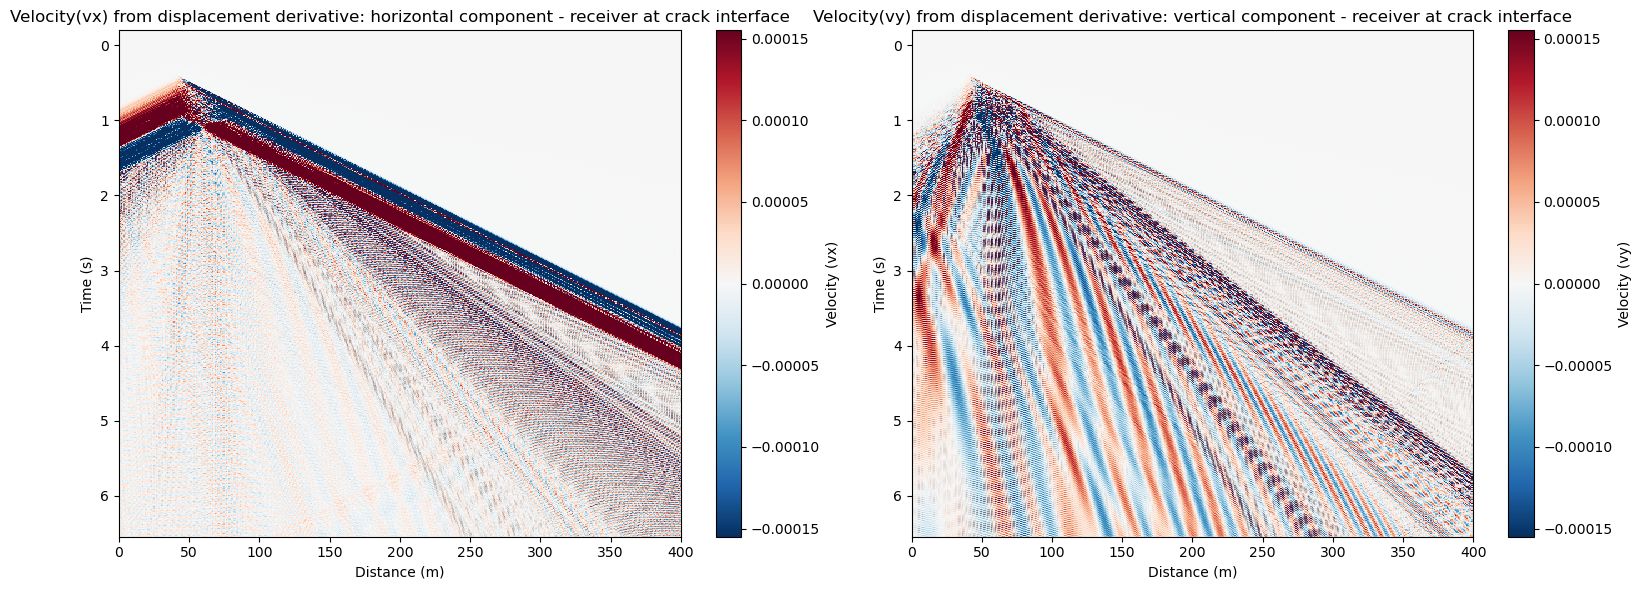

In [20]:
# instead of velocity: temporal derivative of displacement to get velocity
dis_2d_layered_dt = dis_2d_layered.differentiate(t_name)

# plotting displacement temporal derivative (velocity)
# Force inline display in case backend was set to Agg earlier
import matplotlib.pyplot as plt
from IPython.display import display

# Define receiver line 
y_surface = 2.625 # 

# dis_2d_layered is already an xarray built from all events.
# Use direct selection instead of calling wavefield_output_to_xarray again.
    
# Resolve coordinate / dimension names robustly.
coords_set = set(dis_2d_layered_dt.coords)
dims_set = set(dis_2d_layered_dt.dims)

x_name = next((n for n in ["x", "X", "p0", "dim_0"] if n in coords_set or n in dims_set), None)
y_name = next((n for n in ["y", "Y", "p1", "dim_1"] if n in coords_set or n in dims_set), None)
t_name = next((n for n in ["t", "time"] if n in coords_set or n in dims_set), None)
c_name = next((n for n in ["c", "component"] if n in coords_set or n in dims_set), None)
e_name = next((n for n in ["event_index", "event", "source"] if n in coords_set or n in dims_set), None)

if x_name is None or y_name is None or t_name is None or c_name is None:
    raise ValueError(f"Could not resolve required dimensions. Found dims={dis_2d_layered_dt.dims}, coords={list(dis_2d_layered_dt.coords)}")

# Select both components at y receiver line
sg_vx = dis_2d_layered_dt.isel({c_name: 0}).sel({y_name: y_surface}, method="nearest")
sg_vy = dis_2d_layered_dt.isel({c_name: 1}).sel({y_name: y_surface}, method="nearest")

# Keep all moving-source events by reducing event dimension to a single stacked section.
if e_name is not None and e_name in sg_vx.dims:
    sg_vx_plot = sg_vx.mean(dim=e_name)
    sg_vy_plot = sg_vy.mean(dim=e_name)
else:
    sg_vx_plot = sg_vx
    sg_vy_plot = sg_vy

# Ensure plotting order is (time, x)
sg_vx_plot = sg_vx_plot.transpose(t_name, x_name)
sg_vy_plot = sg_vy_plot.transpose(t_name, x_name)

t_vals = sg_vx_plot[t_name].values
x_line = sg_vx_plot[x_name].values
data_vx = sg_vx_plot.values
data_vy = sg_vy_plot.values

print("Using dimensions:", {"x": x_name, "y": y_name, "t": t_name, "c": c_name, "event": e_name})
print("t range:", t_vals[0], "->", t_vals[-1])
print("vx shape:", data_vx.shape)
print("vy shape:", data_vy.shape)

# Clip colorscale (use same scale for both for comparison)
vmax = np.percentile(np.abs([data_vx, data_vy]), 95)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot vx (horizontal component)
im_vx = axes[0].pcolormesh(
    x_line,
    t_vals,
    data_vx,
    shading="none",
    cmap="RdBu_r",
    vmin=-vmax,
    vmax=vmax,
)
axes[0].invert_yaxis()

# Mark all moving source positions
# for x_src in x_positions:
#     axes[0].axvline(x=x_src, color="teal", lw=0.5, linestyle="--", alpha=0.35)

axes[0].set_xlabel("Distance (m)")
axes[0].set_ylabel("Time (s)")
axes[0].set_xlim(0, 400)
axes[0].set_title("Velocity(vx) from displacement derivative: horizontal component - receiver at crack interface")
plt.colorbar(im_vx, ax=axes[0], label="Velocity (vx)")

# Plot vy (vertical component)
im_vy = axes[1].pcolormesh(
    x_line,
    t_vals,
    data_vy,
    shading="none",
    cmap="RdBu_r",
    vmin=-vmax,
    vmax=vmax,
)
axes[1].invert_yaxis()

# # Mark all moving source positions
# for x_src in x_positions:
#     axes[1].axvline(x=x_src, color="teal", lw=0.5, linestyle="--", alpha=0.35)

axes[1].set_xlabel("Distance (m)")
axes[1].set_ylabel("Time (s)")
axes[1].set_xlim(0, 400)
axes[1].set_title("Velocity(vy) from displacement derivative: vertical component - receiver at crack interface")
plt.colorbar(im_vy, ax=axes[1], label="Velocity (vy)")

plt.tight_layout()

# Display explicitly in notebook output
display(fig)
plt.close(fig)

Using dimensions: {'x': 'x', 'y': 'y', 't': 't', 'c': 'c', 'event': None}
t range: -0.2 -> 6.546130527508221
vx shape: (3462, 451)
vy shape: (3462, 451)


/tmp/ipykernel_2436125/4079888971.py:58: UserWarning: shading value 'none' not in list of valid values ['gouraud', 'nearest', 'flat', 'auto']. Setting shading='auto'.
  im_vx = axes[0].pcolormesh(
/tmp/ipykernel_2436125/4079888971.py:80: UserWarning: shading value 'none' not in list of valid values ['gouraud', 'nearest', 'flat', 'auto']. Setting shading='auto'.
  im_vy = axes[1].pcolormesh(


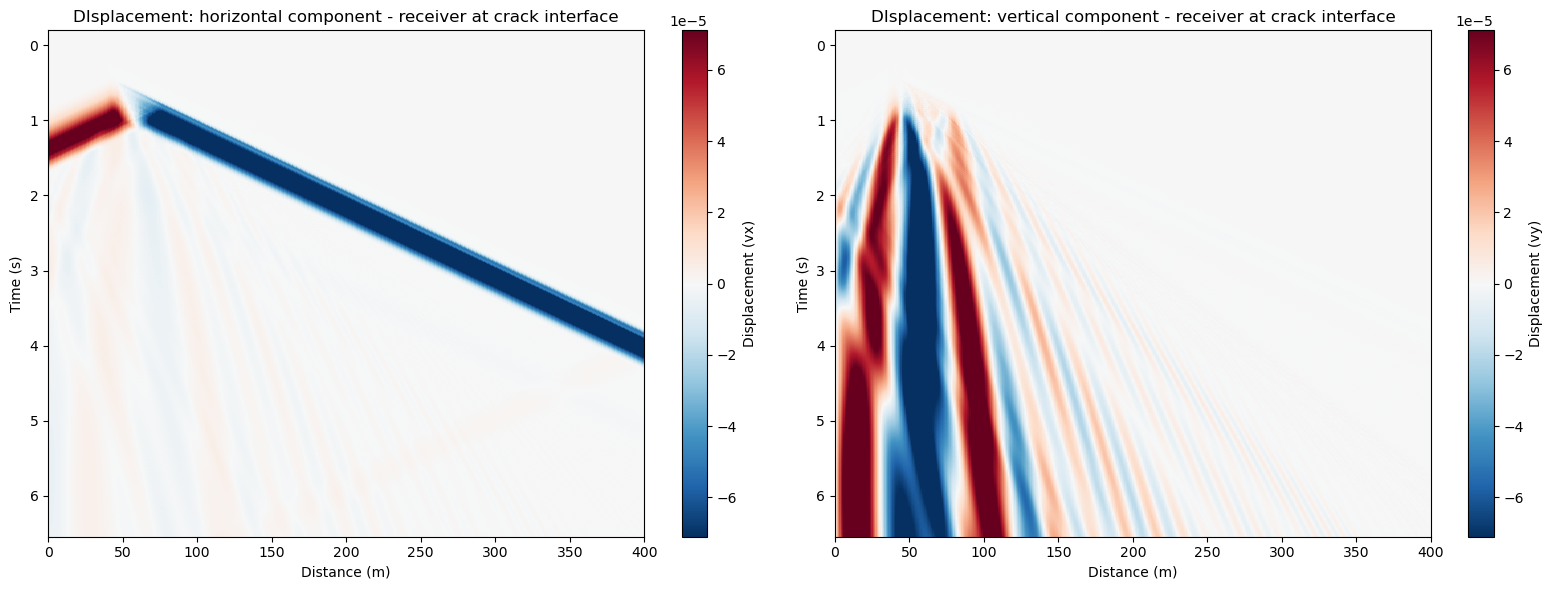

In [21]:
# plotting displacement
# Force inline display in case backend was set to Agg earlier
import matplotlib.pyplot as plt
from IPython.display import display

# Define receiver line 
y_surface = 2.625 

# dis_2d_layered is already an xarray built from all events.
# Use direct selection instead of calling wavefield_output_to_xarray again.
    
# Resolve coordinate / dimension names robustly.
coords_set = set(vel_2d_layered.coords)
dims_set = set(vel_2d_layered.dims)

x_name = next((n for n in ["x", "X", "p0", "dim_0"] if n in coords_set or n in dims_set), None)
y_name = next((n for n in ["y", "Y", "p1", "dim_1"] if n in coords_set or n in dims_set), None)
t_name = next((n for n in ["t", "time"] if n in coords_set or n in dims_set), None)
c_name = next((n for n in ["c", "component"] if n in coords_set or n in dims_set), None)
e_name = next((n for n in ["event_index", "event", "source"] if n in coords_set or n in dims_set), None)

if x_name is None or y_name is None or t_name is None or c_name is None:
    raise ValueError(f"Could not resolve required dimensions. Found dims={vel_2d_layered.dims}, coords={list(vel_2d_layered.coords)}")

# Select both components at y receiver line
dis_vx = dis_2d_layered.isel({c_name: 0}).sel({y_name: y_surface}, method="nearest")
dis_vy = dis_2d_layered.isel({c_name: 1}).sel({y_name: y_surface}, method="nearest")

# Keep all moving-source events by reducing event dimension to a single stacked section.
if e_name is not None and e_name in dis_vx.dims:
    dis_vx_plot = dis_vx.mean(dim=e_name)
    dis_vy_plot = dis_vy.mean(dim=e_name)
else:
    dis_vx_plot = dis_vx
    dis_vy_plot = dis_vy

# Ensure plotting order is (time, x)
dis_vx_plot = dis_vx_plot.transpose(t_name, x_name)
dis_vy_plot = dis_vy_plot.transpose(t_name, x_name)

t_vals = dis_vx_plot[t_name].values
x_line = dis_vx_plot[x_name].values
data_vx = dis_vx_plot.values
data_vy = dis_vy_plot.values

print("Using dimensions:", {"x": x_name, "y": y_name, "t": t_name, "c": c_name, "event": e_name})
print("t range:", t_vals[0], "->", t_vals[-1])
print("vx shape:", data_vx.shape)
print("vy shape:", data_vy.shape)

# Clip colorscale (use same scale for both for comparison)
vmax = np.percentile(np.abs([data_vx, data_vy]), 95)
#vmax = 1e-7

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot vx (horizontal component)
im_vx = axes[0].pcolormesh(
    x_line,
    t_vals,
    data_vx,
    shading="none",
    cmap="RdBu_r",
    vmin=-vmax,
    vmax=vmax,
)
axes[0].invert_yaxis()

# Mark all moving source positions
# for x_src in x_positions:
#     axes[0].axvline(x=x_src, color="teal", lw=0.5, linestyle="--", alpha=0.35)

axes[0].set_xlabel("Distance (m)")
axes[0].set_ylabel("Time (s)")
axes[0].set_xlim(0, 400)
axes[0].set_title("DIsplacement: horizontal component - receiver at crack interface")
plt.colorbar(im_vx, ax=axes[0], label="Displacement (vx)")

# Plot vy (vertical component)
im_vy = axes[1].pcolormesh(
    x_line,
    t_vals,
    data_vy,
    shading="none",
    cmap="RdBu_r",
    vmin=-vmax,
    vmax=vmax,
)
axes[1].invert_yaxis()

# # Mark all moving source positions
# for x_src in x_positions:
#     axes[1].axvline(x=x_src, color="teal", lw=0.5, linestyle="--", alpha=0.35)

axes[1].set_xlabel("Distance (m)")
axes[1].set_ylabel("Time (s)")
axes[1].set_xlim(0, 400)
axes[1].set_title("DIsplacement: vertical component - receiver at crack interface")
plt.colorbar(im_vy, ax=axes[1], label="Displacement (vy)")

plt.tight_layout()

# Display explicitly in notebook output
display(fig)
plt.close(fig)

In [22]:
# # animation 
# # =============================================================================
# # UNIFIED WAVEFIELD ANIMATION ENGINE (Vy & Vx)
# # =============================================================================
# import pathlib
# import numpy as np
# import matplotlib
# import matplotlib.pyplot as plt
# from matplotlib import animation
# from IPython.display import display
# from salvus.toolbox.helpers import wavefield_output

# # Always reload the latest simulation output from disk
# base_dir = globals().get('PROJECT_DIR', "simulation_wavefield_custom_stf_weighted_simpler_mesh_dense")
# project_path = pathlib.Path(base_dir) / "custom_job_moving_source_all_sources"

# output_candidates = sorted(project_path.glob("**/volume_data_output.h5"), key=lambda path: path.stat().st_mtime, reverse=True)
# if not output_candidates:
#     raise RuntimeError(f"Missing output file under {project_path}: volume_data_output.h5")
# vol_file = output_candidates[0]
# print(f"Using latest wavefield file: {vol_file}")

# vel_wo = wavefield_output.WavefieldOutput.from_file(vol_file, "velocity", "volume")
# vel_2d_layered = wavefield_output.wavefield_output_to_xarray(
#     vel_wo,
#     points=[np.linspace(0, 400, 401), np.linspace(0, 3, 101)],
# )

# # Resolve coordinate and dimension naming conventions robustly
# coords_set = set(vel_2d_layered.coords)
# dims_set = set(vel_2d_layered.dims)
# x_name = next((n for n in ["x", "X", "p0", "dim_0"] if n in coords_set or n in dims_set), None)
# y_name = next((n for n in ["y", "Y", "p1", "dim_1"] if n in coords_set or n in dims_set), None)
# t_name = next((n for n in ["t", "time"] if n in coords_set or n in dims_set), None)
# c_name = next((n for n in ["c", "component"] if n in coords_set or n in dims_set), None)
# e_name = next((n for n in ["event_index", "event", "source"] if n in coords_set or n in dims_set), None)

# if None in [x_name, y_name, t_name, c_name]:
#     raise ValueError(f"Could not resolve dimensions from dims={vel_2d_layered.dims}, coords={list(vel_2d_layered.coords)}")

# receiver_y = 2.625

# # =============================================================================
# # PART 1: VERTICAL VELOCITY COMPONENT (vy)
# # =============================================================================
# print("\n--- Processing Animation 1/2: Velocity (vy) ---")
# vy_event = vel_2d_layered.isel({c_name: 1})  # Component 1 = vy
# if e_name is not None and e_name in vy_event.dims:
#     vy_event = vy_event.mean(dim=e_name)
# vy_event = vy_event.transpose(t_name, y_name, x_name)

# x_vals_y = vy_event[x_name].values
# y_vals_y = vy_event[y_name].values
# t_vals_y = vy_event[t_name].values
# frames_3d_y = np.asarray(vy_event.values, dtype=np.float64)
# frames_3d_y = np.nan_to_num(frames_3d_y, nan=0.0, posinf=0.0, neginf=0.0)

# t_start_idx = np.searchsorted(t_vals_y, 0.0)
# N = 8
# raw_idx_y = np.arange(t_start_idx, frames_3d_y.shape[0], N)
# max_frames = 350
# t_idx_y = raw_idx_y[:max_frames]

# # Robust symmetric color scaling
# sample_abs_y = np.abs(frames_3d_y[t_idx_y]).ravel()
# sample_abs_y = sample_abs_y[np.isfinite(sample_abs_y) & (sample_abs_y > 1e-14)]
# vmax_y = max(float(np.percentile(sample_abs_y, 99.0)), 1e-8) if sample_abs_y.size > 0 else 1e-8
# norm_y = matplotlib.colors.TwoSlopeNorm(vcenter=0.0, vmin=-vmax_y, vmax=vmax_y)

# fig_y, ax_y = plt.subplots(figsize=(12, 4), constrained_layout=True)
# im_y = ax_y.imshow(
#     frames_3d_y[t_idx_y[0]],
#     extent=[x_vals_y.min(), x_vals_y.max(), y_vals_y.max(), y_vals_y.min()],
#     aspect="auto",
#     cmap="RdBu_r",
#     norm=norm_y,
#     origin="upper",
#     interpolation="nearest",
# )

# ax_y.axhline(1.5, color="black", lw=1.2, linestyle="--", label=f"snow-air  (y=1.5 m)")
# ax_y.set_xlabel("x (m)")
# ax_y.set_ylabel("Depth (m)")
# ax_y.set_xlim(x_vals_y.min(), x_vals_y.max())
# ax_y.set_ylim(y_vals_y.max(), y_vals_y.min())
# ax_y.legend(loc="upper right", fontsize=8)
# plt.colorbar(im_y, ax=ax_y, label="Velocity (vy)", shrink=0.8)
# title_y = ax_y.set_title(f"Wavefield Velocity(vy) - t = {t_vals_y[t_idx_y[0]]:.4f} s at snow bottom (y=2.25 m)")

# def update_y(frame_idx):
#     ti = t_idx_y[frame_idx]
#     im_y.set_data(frames_3d_y[ti])
#     title_y.set_text(f"Wavefield Velocity(vy) - t = {t_vals_y[ti]:.4f} s")
#     return im_y, title_y

# ani_y = animation.FuncAnimation(fig_y, update_y, frames=len(t_idx_y), interval=90, blit=False)
# output_name_y = "custom_sub_wavefield_2d_moving_vy_crack.gif"
# print(f"Saving {output_name_y}...")
# ani_y.save(output_name_y, writer=animation.PillowWriter(fps=15), dpi=80)
# plt.close(fig_y)
# print(f"Done! Saved as {output_name_y}")


# # =============================================================================
# # PART 2: HORIZONTAL VELOCITY COMPONENT (vx)
# # =============================================================================
# print("\n--- Processing Animation 2/2: Velocity (vx) ---")
# vx_event = vel_2d_layered.isel({c_name: 0})  # Component 0 = vx
# if e_name is not None and e_name in vx_event.dims:
#     vx_event = vx_event.mean(dim=e_name)
# vx_event = vx_event.transpose(t_name, y_name, x_name)

# # Arrays are extracted purely from the independent vx_event structure
# x_vals_x = vx_event[x_name].values
# y_vals_x = vx_event[y_name].values
# t_vals_x = vx_event[t_name].values
# frames_3d_x = np.asarray(vx_event.values, dtype=np.float64)
# frames_3d_x = np.nan_to_num(frames_3d_x, nan=0.0, posinf=0.0, neginf=0.0)

# raw_idx_x = np.arange(np.searchsorted(t_vals_x, 0.0), frames_3d_x.shape[0], N)
# t_idx_x = raw_idx_x[:max_frames]

# sample_abs_x = np.abs(frames_3d_x[t_idx_x]).ravel()
# sample_abs_x = sample_abs_x[np.isfinite(sample_abs_x) & (sample_abs_x > 1e-14)]
# vmax_x = max(float(np.percentile(sample_abs_x, 99.0)), 1e-8) if sample_abs_x.size > 0 else 1e-8
# norm_x = matplotlib.colors.TwoSlopeNorm(vcenter=0.0, vmin=-vmax_x, vmax=vmax_x)

# fig_x, ax_x = plt.subplots(figsize=(12, 4), constrained_layout=True)
# im_x = ax_x.imshow(
#     frames_3d_x[t_idx_x[0]],
#     extent=[x_vals_x.min(), x_vals_x.max(), y_vals_x.max(), y_vals_x.min()],
#     aspect="auto",
#     cmap="RdBu_r",
#     norm=norm_x,
#     origin="upper",
#     interpolation="nearest",
# )

# ax_x.axhline(1.5, color="black", lw=1.2, linestyle="--", label=f"snow-air  (y=1.5 m)")
# ax_x.set_xlabel("x (m)")
# ax_x.set_ylabel("Depth (m)")
# ax_x.set_xlim(x_vals_x.min(), x_vals_x.max())
# ax_x.set_ylim(y_vals_x.max(), y_vals_x.min())
# ax_x.legend(loc="upper right", fontsize=8)
# plt.colorbar(im_x, ax=ax_x, label="Velocity (vx)", shrink=0.8)
# title_x = ax_x.set_title(f"Wavefield Velocity(vx) - t = {t_vals_x[t_idx_x[0]]:.4f} s at crack location (y = 2.625m)")

# def update_x(frame_idx):
#     ti = t_idx_x[frame_idx]
#     im_x.set_data(frames_3d_x[ti])
#     title_x.set_text(f"Wavefield Velocity(vx) - t = {t_vals_x[ti]:.4f} s")
#     return im_x, title_x

# ani_x = animation.FuncAnimation(fig_x, update_x, frames=len(t_idx_x), interval=90, blit=False)

# if animation.writers.is_available("ffmpeg"):
#     writer_x = animation.FFMpegWriter(
#         fps=15,
#         codec="libx264",
#         extra_args=["-pix_fmt", "yuv420p", "-crf", "28"],
#     )
#     output_name_x = "custom_weighted_sub_wavefield_2d_moving_vx_crack.mp4"
# else:
#     writer_x = animation.PillowWriter(fps=10)
#     output_name_x = "custom_weighted_sub_wavefield_2d_moving_vx_crack.gif"

# print(f"Saving {output_name_x}...")
# ani_x.save(output_name_x, writer=writer_x, dpi=80)
# plt.close(fig_x)
# print(f"Done! Saved as {output_name_x}")

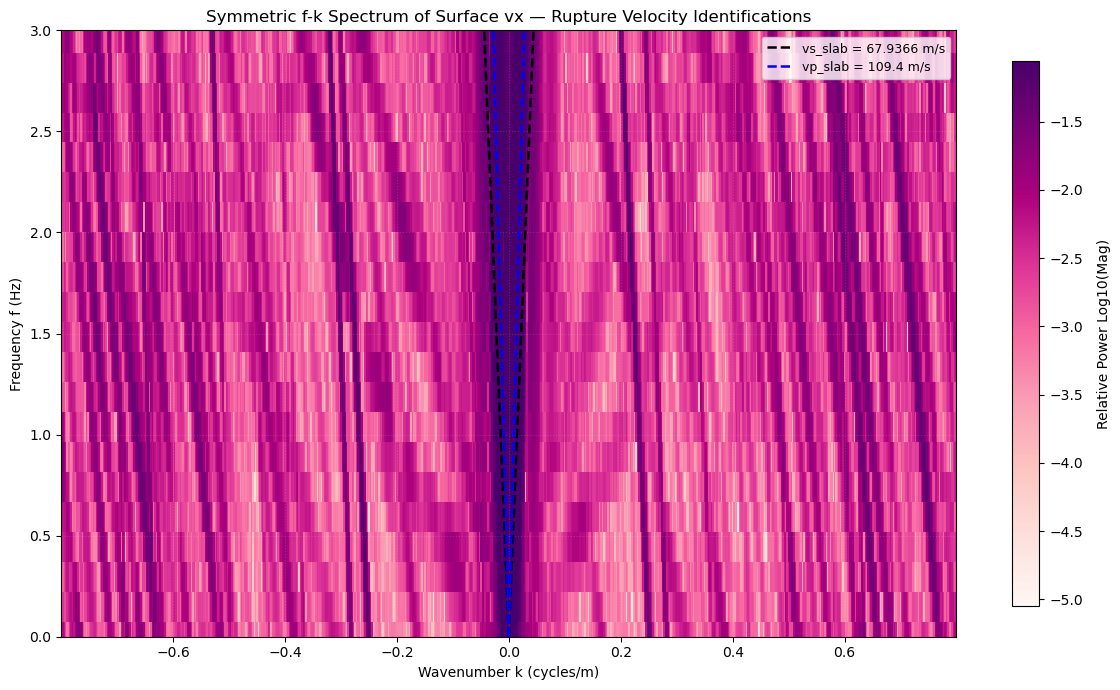

In [27]:
# Frequency domain analysis: f-k analysis with symmetric V-line overlays
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors
from IPython.display import display

# Verify rupture velocity
#print(f"Rupture speed taken is {target_vprop} m/s")

# Surface shot gather selection
y_recv = 2.25   # Snow coordinate target position
# FIX: Changed .isel to .sel so method="nearest" handles physical coordinate mapping correctly
sg = vel_2d_layered.sel(
    {y_name: y_recv},
    method="nearest"
).isel({c_name: 0}) # vx component

t_vals = sg[t_name].values
x_vals = sg[x_name].values
data = sg.values 

# Force data strictly into (nt, nx) shape
if data.shape[0] == len(x_vals):
    data = data.T

nt, nx = data.shape
dt = float(np.nanmedian(np.diff(t_vals)))
dx = float(np.nanmedian(np.diff(x_vals)))

# 2D FFT - f-k spectrum with Hanning Windows
taper_t = np.hanning(nt)
taper_x = np.hanning(nx)
data_tapered = data * taper_t[:, None] * taper_x[None, :]

fk = np.fft.fftshift(np.fft.fft2(data_tapered))
freqs = np.fft.fftshift(np.fft.fftfreq(nt, dt))
wns = np.fft.fftshift(np.fft.fftfreq(nx, dx)) # wavenumber (cycles/m)

# Slice positive frequencies exclusively
f_pos_mask = freqs >= 0
fk_pos = fk[f_pos_mask, :]
# FIX: Properly slice frequency coordinate axis to match pk dimensions
f_plot = freqs[f_pos_mask]

# Define velocity regimes to track
velocities = {
    "vs_slab = 67.9366 m/s": 67.9366,
    #"rupture speed": target_vprop,
    "vp_slab = 109.4 m/s": 109.4,
}
# Match colors array exactly to our 3 dictionary objects
colors = ["black", "blue", "green"]

fig, ax = plt.subplots(figsize=(12, 7))

# Build explicit 2D coordinate meshgrid for flawless pcolormesh mapping
WNS, FREQS = np.meshgrid(wns, f_plot)

# Compute power log spectrum
pk = np.log10(np.abs(fk_pos) + 1e-10)
vmax_pk = np.percentile(pk, 99)
vmin_pk = vmax_pk - 4 # 4 decades of dynamic range

mesh = ax.pcolormesh(
    WNS, FREQS, pk,
    shading="nearest", cmap="RdPu",
    vmin=vmin_pk, vmax=vmax_pk,
)

# Overlay symmetric velocity slopes on both sides of the center (k=0) vertex
k_max = wns.max()
for (label, v), col in zip(velocities.items(), colors):
    # Prograde Slope (Right side of V: k = +f/v)
    k_right = f_plot / v
    mask_right = np.abs(k_right) <= k_max
    ax.plot(k_right[mask_right], f_plot[mask_right], color=col, lw=1.8,
            linestyle="--", label=label)
    
    # Retrograde Slope (Left side of V: k = -f/v)
    # Uses same positive f_plot frequency domain to create full opposing slopes
    k_left = -f_plot / v
    mask_left = np.abs(k_left) <= k_max
    ax.plot(k_left[mask_left], f_plot[mask_left], color=col, lw=1.8,
            linestyle="--") # Omit label here so it doesn't duplicate in legend

ax.set_xlim(-k_max * 0.4, k_max * 0.4)
ax.set_ylim(0, min(3 * f0, freqs.max()))
ax.set_xlabel("Wavenumber k (cycles/m)")
ax.set_ylabel("Frequency f (Hz)")
ax.set_title("Symmetric f-k Spectrum of Surface vx — Rupture Velocity Identifications")
ax.legend(fontsize=9, loc="upper right")
ax.grid(True, alpha=0.15, color="white", linestyle=":")

# Plot matching interactive colorbar mapping
cbar = fig.colorbar(mesh, ax=ax, shrink=0.9)
cbar.set_label("Relative Power Log10(Mag)", labelpad=10)

plt.tight_layout()
display(fig)
plt.close(fig)